# Regional Styles and Patch Evolution in Professional League of Legends (2014–2025)


## 1. Introduction


### Background

Over the past two decades, esports has grown from a niche subculture into a global industry. Among all titles, _League Of Legends_ (LOL) stands out as a defining phenomenon — its annual World Championship now rivals traditional sports finals in viewership. The game also holds a special place in Chinese internet culture: the world titles won by IG (2018, S8), FPX (2019, S9), and EDG (2021, S11) each triggered nationwide celebrations and pushed LoL esports firmly into the mainstream.

Behind the spectacle, professional LoL is also a rich source of structured match data. Every game produces hundreds of measurements — gold, vision, objectives, timing snapshots — across five players per side. This makes it a natural setting for statistical analysis: regional playstyles, meta shifts driven by patches, and the long-term evolution of competitive tempo are all empirically observable rather than merely anecdotal.


### Research Questions

This report focuses on two related questions:

1. **Regional styles.** Do major regions (LPL, LCK, LCS, LEC, and others) display statistically distinguishable playstyles in terms of aggression, early-game economy, vision control, and objective priority?
2. **Patch dynamics.** How have successive game patches reshaped match tempo over 2014–2025, and have they widened or narrowed the stylistic gap between regions?


### Data Source & Scope

All analyses are based on the publicly available **Oracle's Elixir** match dataset, covering professional LoL matches from **2014 through 2025** (twelve full competitive seasons, roughly 1.11 million player-game rows). The 2026 season is excluded because the data is still incomplete at the time of writing.


## 2. Data Overview


### Preparations


In [1]:
"""Global imports for the entire report.

All code cells throughout the notebook rely on the packages imported here,
so this cell should be run first after kernel restart.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import seaborn as sns
from sklearn import decomposition, preprocessing
from tqdm.auto import tqdm

from utils.completness import first_usable_year, missing_rate_by_year
from utils.data_loader import load_all_seasons
from utils.preprocess import (
    filter_complete,
    get_player_rows,
    get_team_rows,
    standard_clean,
    require_snapshots,
)
from utils.regions import REGION_ORDER, add_region
from utils.mertics import (
    aggression,
    early_dominance,
    vision_control,
    objective_focus,
    build_playstyle_table,
)


# Display & plotting defaults
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Project paths
DATA_DIR = Path("data")
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

### Dataset Structure & Key Fields


In [2]:
df = load_all_seasons()
print(f"Total rows:   {len(df):,}")
print(f"Total cols:   {df.shape[1]}")
print(f"Years:        {sorted(df['year'].unique())}")
print(f"Memory:       {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Total rows:   1,118,796
Total cols:   165
Years:        [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Memory:       1725.8 MB


,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,participantid,side,position,playername,playerid,teamname,teamid,firstPick,champion,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,doublekills,triplekills,quadrakills,pentakills,...,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15,goldat20,xpat20,csat20,opp_goldat20,opp_xpat20,opp_csat20,golddiffat20,xpdiffat20,csdiffat20,killsat20,assistsat20,deathsat20,opp_killsat20,opp_assistsat20,opp_deathsat20,goldat25,xpat25,csat25,opp_goldat25,opp_xpat25,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,1,Blue,top,sOAZ,oe:player:e4e943fa882367a96fb2a365de4e28c,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Trundle,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,3,0,13,21,5,0.0,0.0,0.0,0.0,...,111.0,49.0,-560.0,-1.0,2.0,0.0,0.0,1.0,1.0,1.0,6958.0,9467.0,166.0,6572.0,10098.0,157.0,386.0,-631.0,9.0,3.0,0.0,0.0,1.0,2.0,1.0,8735.0,12111.0,188.0,8659.0,12623.0,206.0,76.0,-512.0,-18.0,3.0,4.0,0.0,1.0,2.0,2.0
1,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,2,Blue,jng,Cyanide,oe:player:e4cd1e7b68ee6b595a6e4c7cd2c56d8,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Vi,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,0,4,14,21,5,0.0,0.0,0.0,0.0,...,95.0,-1107.0,-703.0,-36.0,0.0,2.0,2.0,2.0,0.0,0.0,5300.0,8598.0,85.0,6504.0,8885.0,115.0,-1204.0,-287.0,-30.0,0.0,3.0,3.0,2.0,1.0,0.0,7122.0,11230.0,98.0,8010.0,10879.0,140.0,-888.0,351.0,-42.0,0.0,5.0,3.0,2.0,1.0,1.0
2,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,3,Blue,mid,xPeke,oe:player:5d69aabb447fa09188638716fe549b6,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Orianna,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,10,1,7,21,5,4.0,1.0,0.0,0.0,...,126.0,-145.0,-148.0,7.0,0.0,1.0,1.0,0.0,2.0,0.0,6740.0,10454.0,194.0,6858.0,10220.0,178.0,-118.0,234.0,16.0,0.0,2.0,1.0,1.0,2.0,0.0,9312.0,13117.0,233.0,8691.0,12384.0,225.0,621.0,733.0,8.0,1.0,5.0,1.0,1.0,2.0,0.0
3,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,4,Blue,bot,Rekkles,oe:player:d8362fe0d38ca0e70953ed957deaa00,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Jinx,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,8,0,9,21,5,2.0,1.0,0.0,0.0,...,103.0,1588.0,998.0,22.0,3.0,0.0,0.0,0.0,0.0,3.0,7537.0,7884.0,181.0,5637.0,7246.0,143.0,1900.0,638.0,38.0,3.0,1.0,0.0,0.0,0.0,3.0,10279.0,11126.0,211.0,7014.0,9176.0,161.0,3265.0,1950.0,50.0,6.0,2.0,0.0,0.0,0.0,4.0
4,TRLH3/33,complete,http://matchhistory.na.leagueoflegends.com/en/...,EU LCS,2014,Spring,0,2014-01-14 17:52:02,1.0,3.15,5,Blue,sup,YellOwStaR,oe:player:5ebcf3b41dc66e5839da4c5f58bd907,Fnatic,oe:team:78f183fa5a7d8ecb22b9ad272c3abd7,NaN,Annie,Riven,Kha'Zix,Yasuo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1924,1,0,0,15,21,5,0.0,0.0,0.0,0.0,...,23.0,887.0,476.0,-15.0,0.0,4.0,0.0,0.0,0.0,1.0,4524.0,6100.0,8.0,3452.0,5229.0,24.0,1072.0,871.0,-16.0,0.0,4.0,0.0,0.0,1.0,2.0,6277.0,8865.0,9.0,4497.0,6468.0,28.0,1780.0,2397.0,-19.0,0.0,7.0,0.0,0.0,1.0,3.0


### Data Completeness Across Years

Early years caveat.


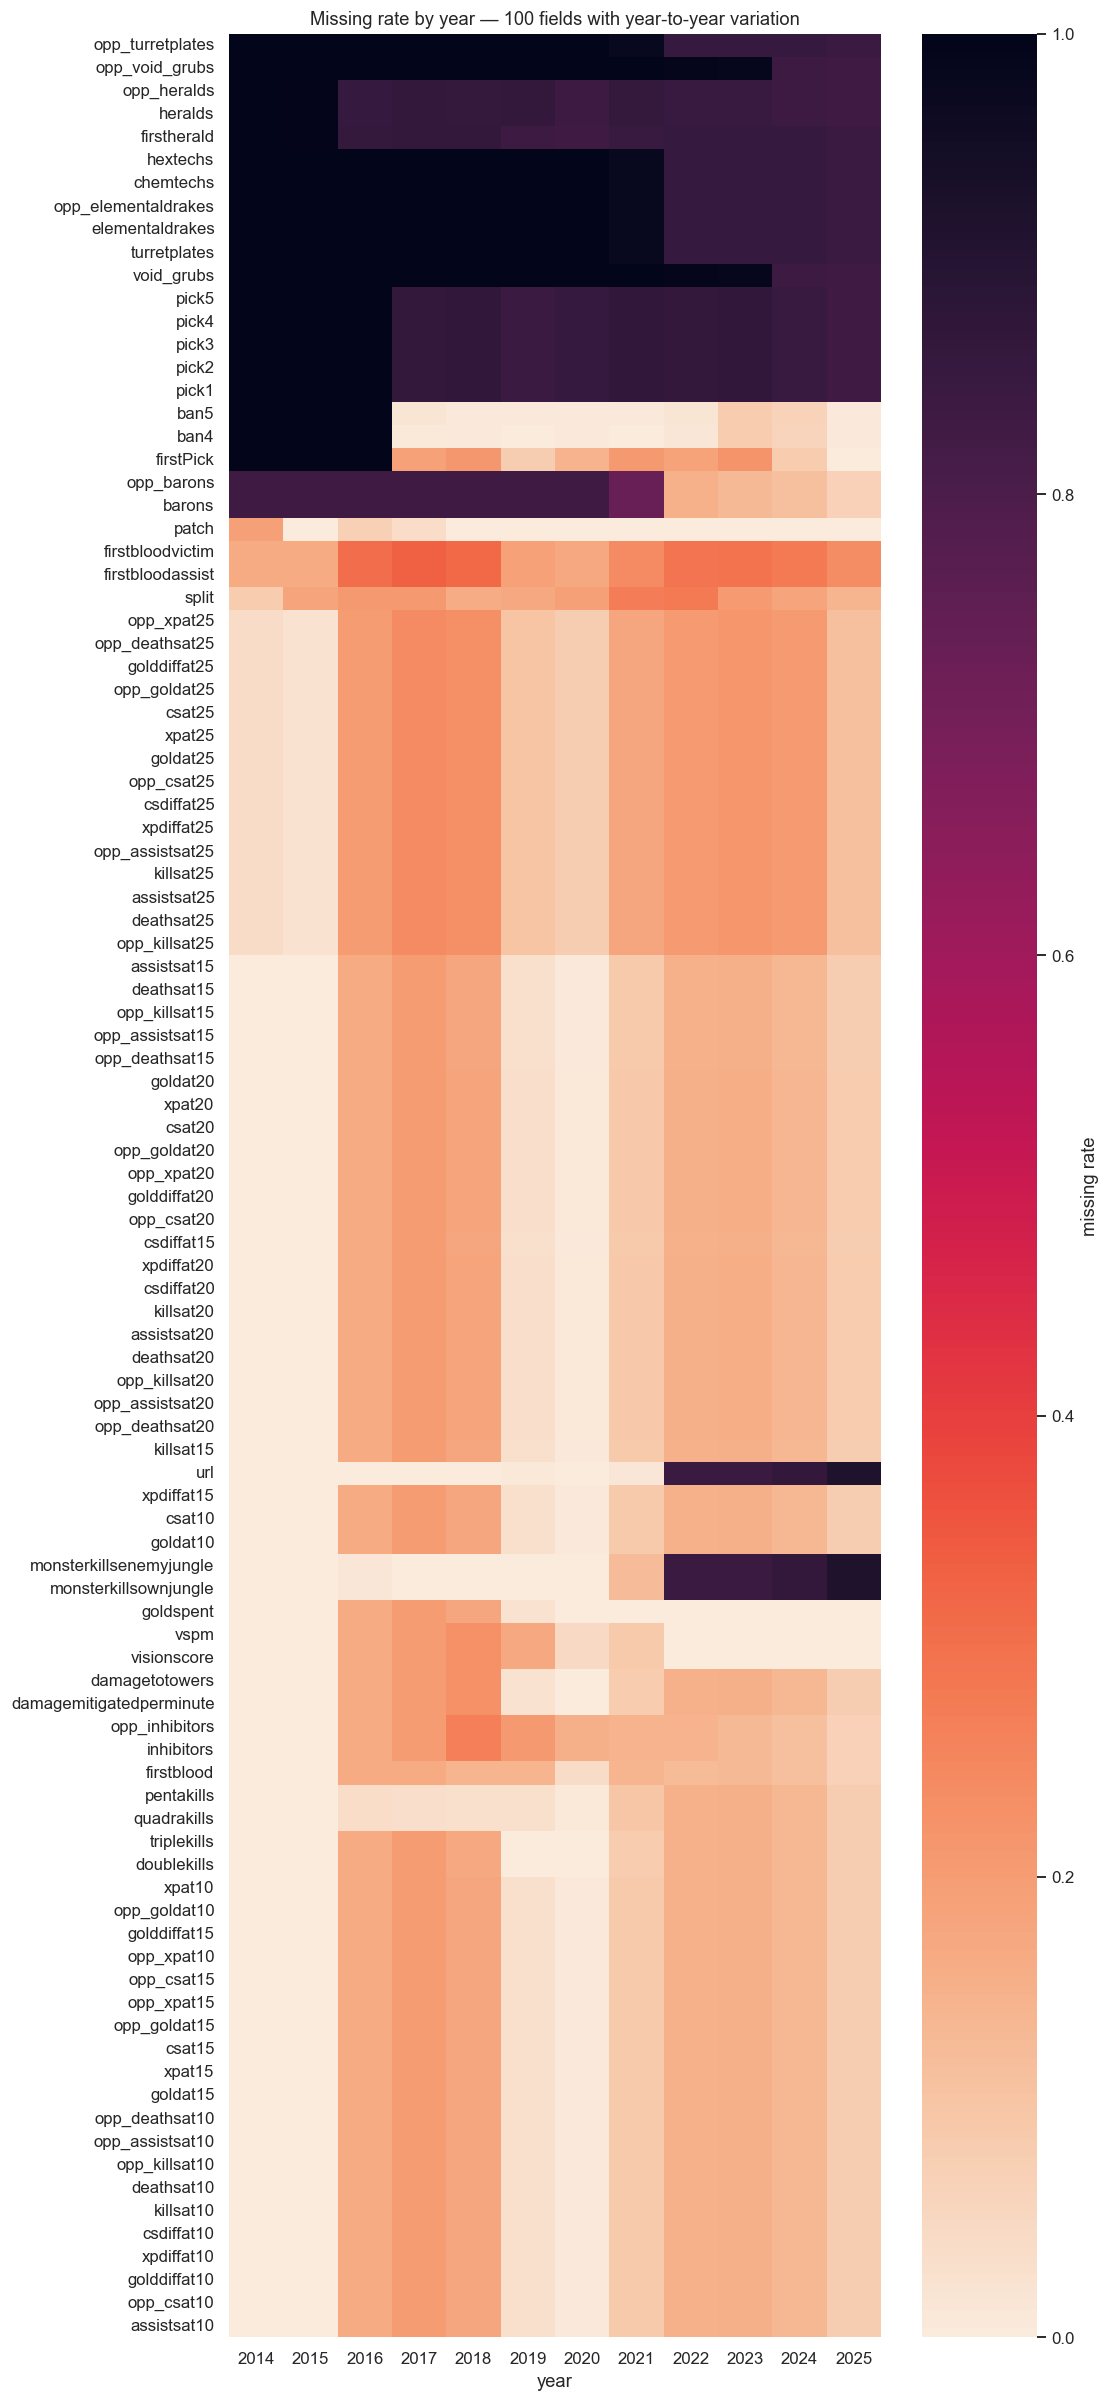

,first_usable_year
gameid,2014
opp_killsat15,2014
deathsat15,2014
assistsat15,2014
killsat15,2014
...,...
ban4,2017
ban5,2017
firstPick,2019
opp_barons,2025


In [3]:
miss = missing_rate_by_year(df=df)

varying = miss.columns[miss.std() > 0.05]
heat = miss[varying].T.sort_values(2014, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(varying) * 0.22)))
sns.heatmap(heat, cmap="rocket_r", vmin=0, vmax=1, cbar_kws={"label": "missing rate"}, ax=ax)
ax.set_title(f"Missing rate by year — {len(varying)} fields with year-to-year variation")
plt.tight_layout()
plt.show()

first_usable_year(miss).dropna().sort_values().to_frame()

We find that, our dataset covers 119 competitions or leagues. Major region (LPL / LCK / LCS / LEC) sums up to 17000 games, which take parts of 15% of all games. The rests are subleagues or academy games. In our chapter 5, we only uses main region, and take others in to account if needed. International of subleagues will be processed singly or give out.


### Regions Included & Sample Sizes


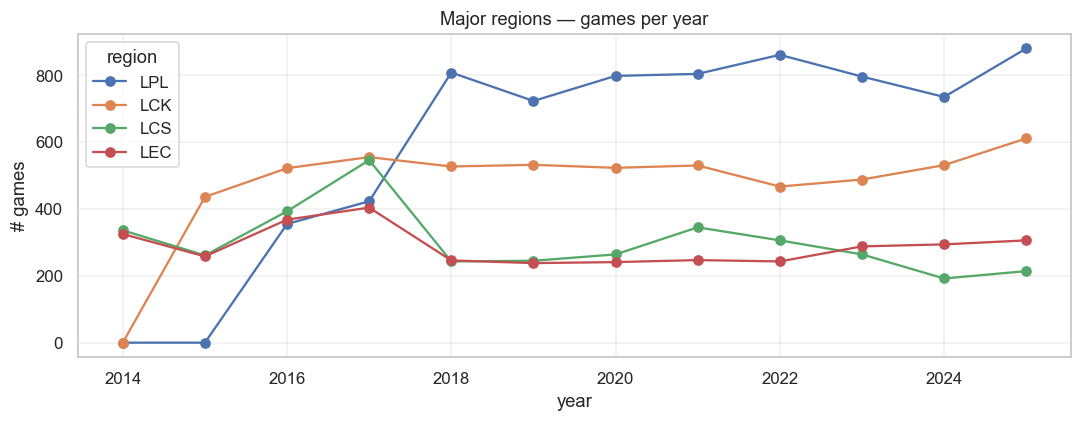

In [4]:
df = add_region(df)

# Competitions of each region
region_year = (
    df.drop_duplicates("gameid")
    .groupby(["region", "year"])
    .size()
    .unstack(fill_value=0)
    .reindex(REGION_ORDER)
)

# Visualize
main = region_year.loc[["LPL", "LCK", "LCS", "LEC"]]
fig, ax = plt.subplots(figsize=(10, 4))
main.T.plot(ax=ax, marker="o")
ax.set_title("Major regions — games per year")
ax.set_ylabel("# games")
ax.legend(title="region")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Preprocessing Decisions

e.g., excluding incomplete rows, separating team rows vs. player rows.


In [5]:
# check data structure
print("=== Row structure ===")
print(f"Total rows:        {len(df):,}")
print(
    f"Player rows:       {len(get_player_rows(df)):,}  ({len(get_player_rows(df)) / len(df):.1%})"
)
print(f"Team rows:         {len(get_team_rows(df)):,}  ({len(get_team_rows(df)) / len(df):.1%})")
print(f"Unique games:      {df['gameid'].nunique():,}")

# Filter the effects of decision
print("=== Filtering impact (on game count) ===")
n_total = df["gameid"].nunique()
n_complete = filter_complete(df)["gameid"].nunique()
n_clean = standard_clean(df)["gameid"].nunique()
print(f"All games:                       {n_total:,}")
print(f"... after datacompleteness only: {n_complete:,}  (-{n_total - n_complete:,})")
print(f"... after standard_clean:        {n_clean:,}  (-{n_total - n_clean:,})")


=== Row structure ===
Total rows:        1,118,796
Player rows:       932,330  (83.3%)
Team rows:         186,466  (16.7%)
Unique games:      93,233
=== Filtering impact (on game count) ===
All games:                       93,233
... after datacompleteness only: 82,511  (-10,722)
... after standard_clean:        93,227  (-6)


Rules of preprocessing:

- Players (KDA, CSPM, Vision Scores, etc): `get_player_rows()`, 12 rows/game
- Games (Winner, Dragon/Baron, golddiff, etc): `get_team_rows()`, 2 rows/game

1. `datacompleteness == 'complete'`: filter some missing data.
2. `gamelength >= 900s`: filter remake/surrender.


## 3. The Evolution of the Game (Macro Trends, 2014–2025)


Using data processor, we fetch and process to get cleaned data.


In [6]:
games = (
    standard_clean(df)
    .pipe(get_team_rows)
    .pipe(add_region)
    .drop_duplicates("gameid")
    .assign(gamelength_min=lambda d: d["gamelength"] / 60)
)
print(f"Games after standard_clean: {len(games):,}")

Games after standard_clean: 93,227


### Match Duration Over the Years


First, let's see how game duration change over the years.


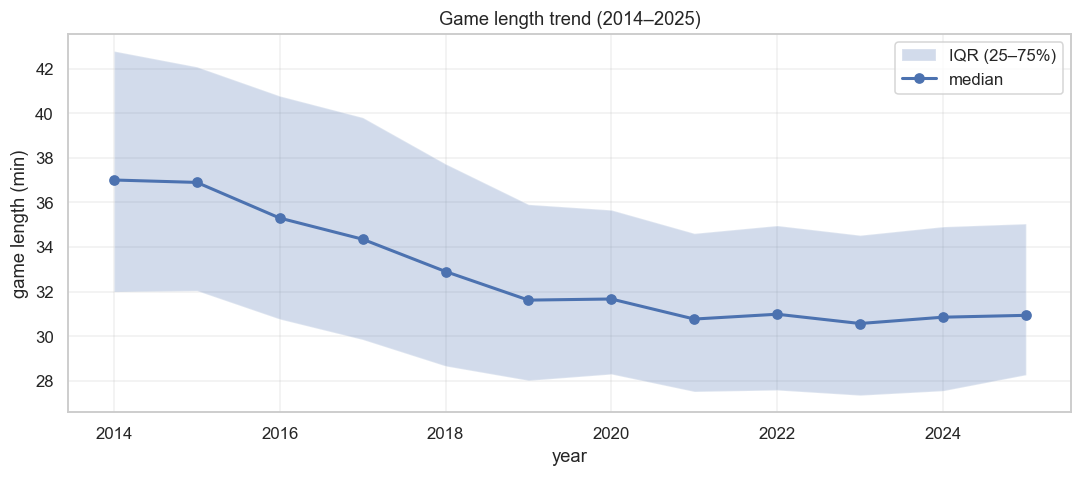

In [7]:
yearly = games.groupby("year")["gamelength_min"].agg(
    median="median", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(yearly.index, yearly["q25"], yearly["q75"], alpha=0.25, label="IQR (25–75%)")
ax.plot(yearly.index, yearly["median"], marker="o", linewidth=2, label="median")
ax.set_title("Game length trend (2014–2025)")
ax.set_ylabel("game length (min)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


Precisely, let's see game duration of each region.


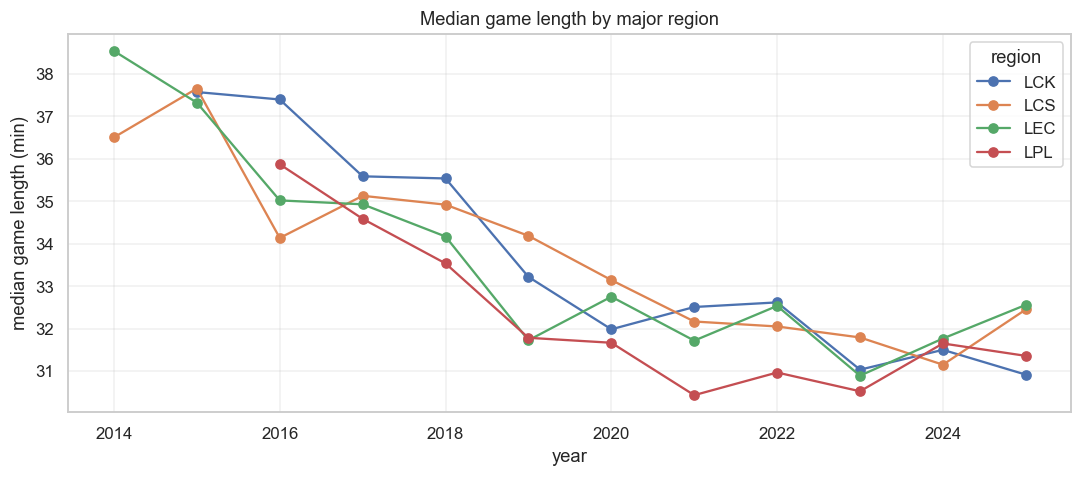

In [8]:
main_regions = ["LPL", "LCK", "LCS", "LEC"]
by_region = (
    games[games["region"].isin(main_regions)]
    .groupby(["year", "region"])["gamelength_min"]
    .median()
    .unstack("region")
)

fig, ax = plt.subplots(figsize=(10, 4.5))
by_region.plot(ax=ax, marker="o")
ax.set_title("Median game length by major region")
ax.set_ylabel("median game length (min)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ax.legend(title="region")
plt.tight_layout()
plt.show()

然后看整体分布的 boxplot，看看离群值


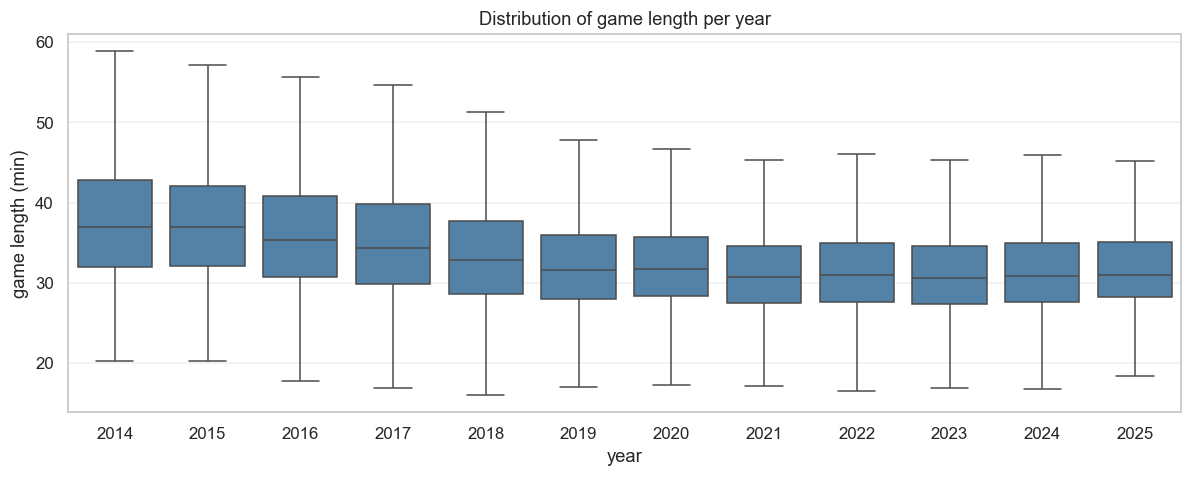

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(
    data=games,
    x="year",
    y="gamelength_min",
    showfliers=False,
    color="steelblue",
    ax=ax,
)
ax.set_title("Distribution of game length per year")
ax.set_ylabel("game length (min)")
ax.set_xlabel("year")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Kill Pace (Kills per Minute) Over the Years


In [10]:
games_kpm: pd.DataFrame = (
    standard_clean(df)
    .pipe(get_team_rows)
    .pipe(add_region)
    .groupby(["gameid", "year", "region", "gamelength"], as_index=False)["kills"]
    .sum()
    .assign(
        gamelength_min=lambda d: d["gamelength"] / 60,
        kpm=lambda d: d["kills"] / (d["gamelength"] / 60),
    )
)

print(f"Games for KPM analysis: {len(games_kpm):,}")
games_kpm[["year", "kills", "gamelength_min", "kpm"]].describe()

Games for KPM analysis: 93,227


,year,kills,gamelength_min,kpm
count,93227.000000,93227.000000,93227.000000,93227.000000
mean,2020.987750,28.397439,32.473182,0.892801
std,2.771123,9.782715,6.316814,0.314750
min,2014.000000,1.000000,15.183333,0.046729
25%,2019.000000,21.000000,28.100000,0.669800
50%,2021.000000,27.000000,31.550000,0.857143
75%,2023.000000,34.000000,35.966667,1.072424
max,2025.000000,109.000000,94.666667,3.854875


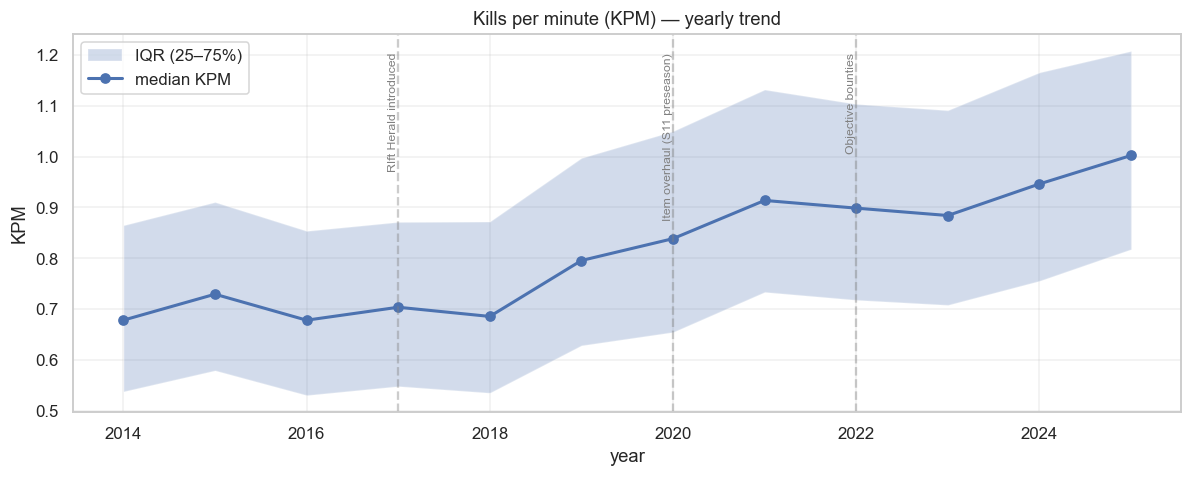

In [11]:
yearly_kpm = games_kpm.groupby("year")["kpm"].agg(
    median="median",
    q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75),
    mean="mean",
)


fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(
    yearly_kpm.index, yearly_kpm["q25"], yearly_kpm["q75"], alpha=0.25, label="IQR (25–75%)"
)
ax.plot(yearly_kpm.index, yearly_kpm["median"], marker="o", lw=2, label="median KPM")

# Some key time
PATCH_MARKERS = {
    2017: "RIft Herald introduced",
    2020: "Item overhaul (S11 preseason)",
    2022: "Objective bounties",
}
for y, label in PATCH_MARKERS.items():
    ax.axvline(y, color="gray", ls="--", alpha=0.4)
    ax.text(
        y,
        ax.get_ylim()[1] * 0.97,
        label,
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        color="gray",
    )


ax.set_title("Kills per minute (KPM) — yearly trend")
ax.set_xlabel("year")
ax.set_ylabel("KPM")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Similarly, we consider aggregation shown in different regions.


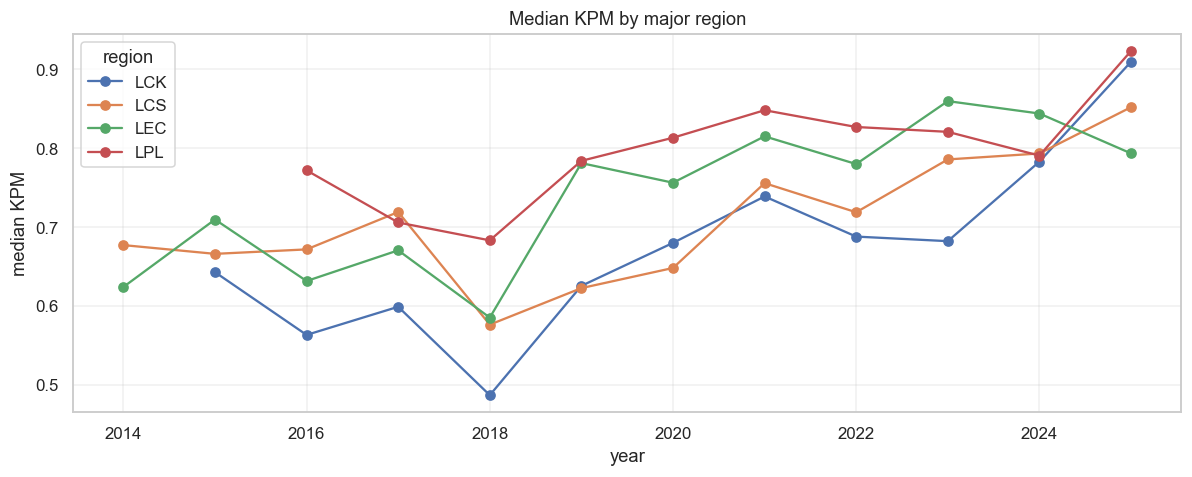

In [12]:
main_regions = ["LPL", "LCK", "LCS", "LEC"]
region_kpm = (
    games_kpm[games_kpm["region"].isin(main_regions)]
    .groupby(["year", "region"])["kpm"]
    .median()
    .unstack("region")
)

fig, ax = plt.subplots(figsize=(11, 4.5))
region_kpm.plot(ax=ax, marker="o")
ax.set_title("Median KPM by major region")
ax.set_xlabel("year")
ax.set_ylabel("median KPM")
ax.grid(alpha=0.3)
ax.legend(title="region")
plt.tight_layout()
plt.show()


### Early-Game vs. Late-Game Resource Distribution Trends


Prepare every year's snapshots.


Public resources also affect game tempo.


In [13]:
snap = standard_clean(df).pipe(require_snapshots).pipe(get_team_rows).pipe(add_region)

snapshot_cols = [
    "goldat10",
    "goldat15",
    "goldat20",
    "goldat25",
    "xpat10",
    "xpat15",
    "xpat20",
    "xpat25",
]

print(f"Games with snapshot data: {snap['gameid'].nunique():,}")
print("\nSnapshot coverage by year:")
print(snap.drop_duplicates("gameid").groupby("year").size())

Games with snapshot data: 82,507

Snapshot coverage by year:
year
2014      918
2015     1815
2016     3515
2017     4399
2018     5433
2019     7653
2020     9615
2021    11123
2022    10641
2023     9372
2024     8802
2025     9221
dtype: int64


Golds


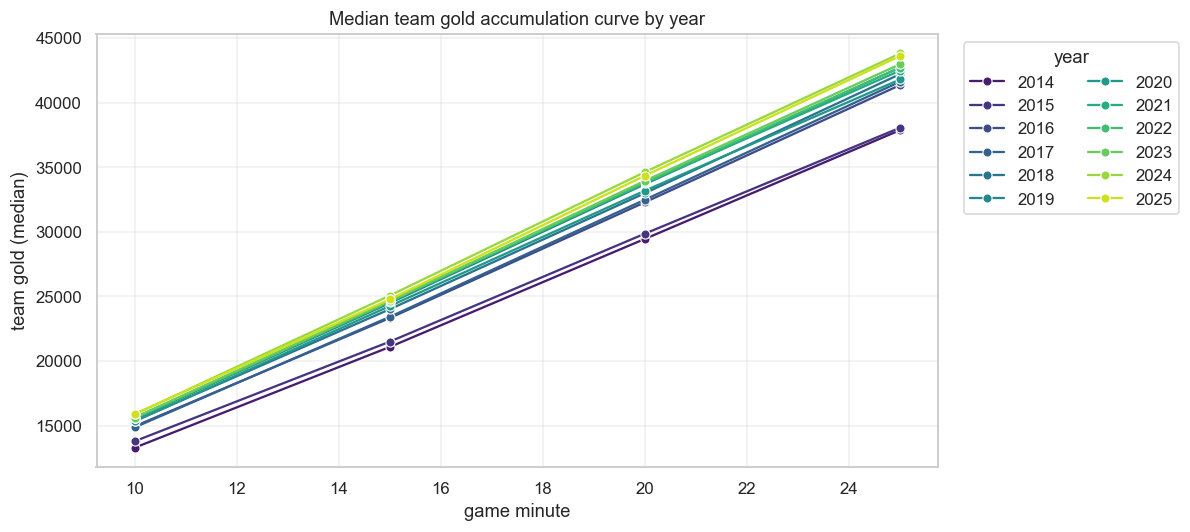

In [14]:
gold_cols = ["goldat10", "goldat15", "goldat20", "goldat25"]
gold_by_year = snap.groupby("year")[gold_cols].median()
gold_long = gold_by_year.reset_index().melt(id_vars="year", var_name="snapshot", value_name="gold")
gold_long["minute"] = gold_long["snapshot"].str.extract(r"(\d+)").astype(int)
gold_long["year"] = gold_long["year"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=gold_long,
    x="minute",
    y="gold",
    hue="year",
    palette="viridis",
    marker="o",
    ax=ax,
)
ax.set_title("Median team gold accumulation curve by year")
ax.set_xlabel("game minute")
ax.set_ylabel("team gold (median)")
ax.grid(alpha=0.3)
ax.legend(title="year", bbox_to_anchor=(1.02, 1), loc="upper left", ncols=2)
plt.tight_layout()
plt.show()


Early proposition.


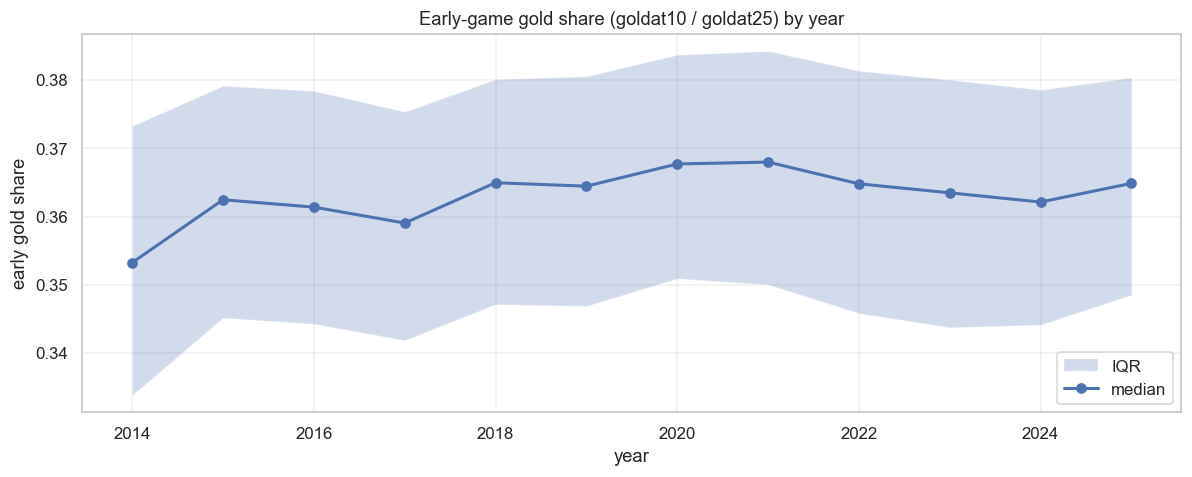

In [15]:
gold_share = (
    snap.assign(early_share=lambda d: d["goldat10"] / d["goldat25"])
    .groupby("year")["early_share"]
    .agg(median="median", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(gold_share.index, gold_share["q25"], gold_share["q75"], alpha=0.25, label="IQR")
ax.plot(gold_share.index, gold_share["median"], marker="o", lw=2, label="median")
ax.set_title("Early-game gold share (goldat10 / goldat25) by year")
ax.set_ylabel("early gold share")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


Gold diff


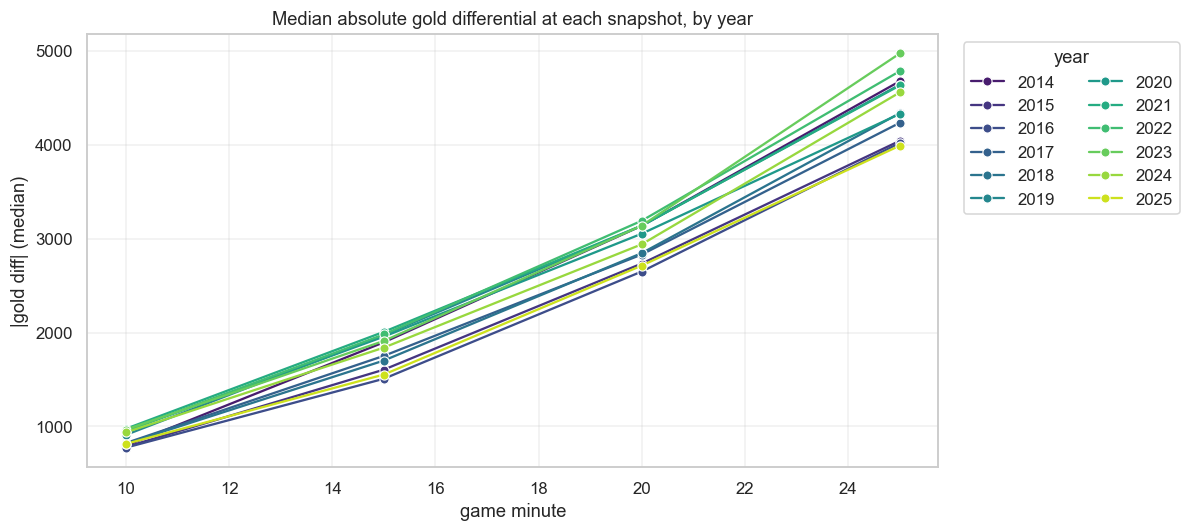

In [16]:
gdiff_cols = ["golddiffat10", "golddiffat15", "golddiffat20", "golddiffat25"]
# golddiffat 对队伍行是有正负的（领先方 +，落后方 -），取绝对值看"差距大小"
gdiff_long = (
    snap[["year"] + gdiff_cols]
    .assign(**{c: snap[c].abs() for c in gdiff_cols})
    .groupby("year")[gdiff_cols]
    .median()
    .reset_index()
    .melt(id_vars="year", var_name="snapshot", value_name="abs_diff")
)
gdiff_long["minute"] = gdiff_long["snapshot"].str.extract(r"(\d+)").astype(int)
gdiff_long["year"] = gdiff_long["year"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=gdiff_long,
    x="minute",
    y="abs_diff",
    hue="year",
    palette="viridis",
    marker="o",
    ax=ax,
)
ax.set_title("Median absolute gold differential at each snapshot, by year")
ax.set_xlabel("game minute")
ax.set_ylabel("|gold diff| (median)")
ax.grid(alpha=0.3)
ax.legend(title="year", bbox_to_anchor=(1.02, 1), loc="upper left", ncols=2)
plt.tight_layout()
plt.show()


### Key Patch Milestones

下表整理 2014–2025 期间对**比赛节奏、目标资源、视野系统、早期博弈**有显著影响的版本节点，作为后续 KPM、游戏时长、视野指标趋势变化的参考时间轴。

| Patch | 大致时间                 | 类别        | 关键改动                                                           | 对比赛的影响                                    |
| ----- | ------------------------ | ----------- | ------------------------------------------------------------------ | ----------------------------------------------- |
| 4.x   | 2014 S4                  | 基线        | 早期赛季，无峡谷先锋 / 大龙魂 / 元素龙增益                         | 节奏慢、运营导向，gamelength 偏长               |
| 5.22  | 2015-11                  | 资源        | **元素龙**（火/水/风/土）取代固定属性龙                            | 龙开始具备战略差异，争夺更频繁                  |
| 6.9   | 2016-04                  | 装备        | **刺客大改**（双瑞文、卡兹克、阿卡丽等）                           | 中野节奏加快，单杀比例上升                      |
| 6.22  | 2016-11 (preseason 7)    | 资源 / 节奏 | **峡谷先锋（Rift Herald）首次引入**；植物系统；视野得分公式调整    | 上路/野区博弈点新增，前期目标增多               |
| 7.22  | 2017-11 (preseason 8)    | 系统        | **符文重铸（Runes Reforged）** 取代旧符文+天赋                     | 出装与对线节奏整体重构                          |
| 8.11  | 2018-05                  | 资源        | 峡谷先锋可在 8 分钟前激活；河蟹改动                                | 早期视野/经济战收益变大                         |
| 9.13  | 2019-07                  | 资源        | **大龙（Baron）增益削弱**，价值后移                                | 大龙不再"一波终结"，比赛时长拉长                |
| 9.23  | 2019-11 (preseason 10)   | 资源        | **大龙魂（Dragon Soul）+ 元素崛起（Elemental Rifts）+ 远古龙**     | 第 4 条龙的战略意义剧增，团战集中后期           |
| 10.23 | 2020-11 (preseason 11)   | 装备        | **神话装备系统**（Mythic Items）大改装备树                         | 多英雄定位重置，出装影响整体节奏                |
| 11.4  | 2021-02                  | 资源        | 化学男爵（Chemtech Drake）首次加入                                 | 龙池扩大，目标博弈更复杂                        |
| 12.5  | 2022-03                  | 资源        | **目标资金（Objective Bounties）**：劣势方击杀大型目标可获额外金钱 | 弱势方追平机会增加，gamelength 偏长且翻盘率提升 |
| 12.14 | 2022-07                  | 资源        | 龙池调整、虚空蛹虫（Void Grubs）测试                               | 上半区野怪博弈细化                              |
| 13.1  | 2023-01                  | 资源        | **虚空蛹虫（Voidgrubs）正式取代峡谷先锋前置**，上半区资源固定化    | 早期上半区博弈节奏更标准化                      |
| 13.10 | 2023-05                  | 装备        | **耐久度补丁（Durability Patch）**：全英雄基础生命/护甲大幅上调    | 单杀难度上升，团战时间延长，KPM 短期下降        |
| 14.1  | 2024-01 (preseason none) | 装备        | **神话装备系统取消**，装备池重构；新增地图植物/野怪改动            | 出装多样性回归，早中期节奏再次调整              |
| 14.10 | 2024-05                  | 资源        | 大龙形态多样化（Baron Variants）                                   | 大龙战略增加变数                                |
| 15.1  | 2025-01                  | 资源        | **新地图大型生物 Atakhan** 加入，野区/大龙窗口调整                 | 团战触发点新增，节奏进一步加快                  |

**引用说明**：本表基于 Riot 官方 Patch Notes，仅列出对宏观比赛指标（KPM、gamelength、视野、目标资源）有可观测影响的版本。具体改动以官方公告为准。


## 4. Defining "Playstyle" — Metrics & Framework

为了系统比较赛区与版本之间的差异，我们将"playstyle"拆解为五个可量化的维度。每个维度由若干来自 Oracle's Elixir 的字段衍生计算，**聚合粒度**统一到 _(team, season)_：每支队伍每年一行，便于后续做赛区均值/分布对比和统计检验。

| 维度                                           | 字段（聚合粒度：team-season）                                              | 计算方式                                                                                                            | 解读                                   |
| ---------------------------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------- | -------------------------------------- |
| **Aggression**<br>对线/团战进攻性              | `kills`, `gamelength`, `firstblood`, `golddiffat15`                        | • KPM = Σkills / Σgamelength_min<br>• First Blood Rate = mean(firstblood)<br>• 15 分钟金币优势 = mean(golddiffat15) | 数值越高 = 越倾向主动开战 / 早期施压   |
| **Early-Game Dominance**<br>前期建立优势的能力 | `csdiffat10`, `golddiffat10`, `xpdiffat10`                                 | 全部取队伍平均                                                                                                      | 数值越高 = 早期对线/野区建立优势越稳定 |
| **Vision Control**<br>视野与地图信息           | `visionscore`, `wardsplaced`, `wardskilled`, `controlwardsbought`          | 全部取队伍平均（已按选手聚合到队伍）                                                                                | 数值越高 = 视野投入越大 / 信息战越激进 |
| **Objective Focus**<br>地图资源争夺            | `firstdragon`, `dragons`, `firstbaron`, `barons`, `firstherald`, `heralds` | First-X 字段取 mean（= 拿取率），数量字段取 mean                                                                    | 数值越高 = 越优先争夺中立资源          |
| **Macro Tempo**<br>整体节奏                    | `gamelength`, `kpm`（衍生）                                                | gamelength 直接取中位数；KPM 与 Aggression 共用                                                                     | gamelength 越短 / KPM 越高 = 节奏越快  |

### 选取这些指标的理由

1. **覆盖比赛阶段**：early-game dominance 看前 10 分钟，aggression 看 15 分钟前后的冲突倾向，objective focus 看中后期资源争夺，macro tempo 看整体节奏——四个时段各有侧重。
2. **可比性**：所有指标都能按 _(team, season)_ 聚合并对赛区平均，避免单场样本噪声。
3. **数据可用性**：早期年份（2014–2016）部分时间快照字段缺失（参见 §2 Data Completeness），涉及 `*at10/15/20/25` 的维度（Early-Game Dominance, 部分 Aggression）将限定在数据完整的年份范围内分析。
4. **维度间的独立性**：5 个维度虽然有相关性（如 aggression 高的队伍 macro tempo 通常也快），但分别测量不同的行为偏好，组合起来构成"赛区指纹"。

### 聚合粒度说明

- **选手层指标**（视野字段）：先按 (gameid, teamname) 求和或平均，再聚合到 (team, season)
- **队伍层指标**（gold diff, kills, objectives）：直接从 team 行（participantid 100/200）取数
- **不区分胜负**：playstyle 是行为倾向，不应被结果偏置（虽然胜利队伍 KDA 自然更好，但 KPM 反映的是"打得多激进"，与胜负相关性弱）

后续 §4.1–§4.5 分别落地每个维度的具体计算，结果汇总到一张 (team, season, metric) 长表，供 §5 赛区对比直接使用。


### Aggression

KPM, first blood rate, golddiff@15.


In [17]:
agg_df = aggression(df)
print(f"team-season rows: {len(agg_df):,}")
print(f"teams: {agg_df['teamname'].nunique()},  years: {sorted(agg_df['year'].unique())}")
agg_df.head()

team-season rows: 5,395
teams: 2305,  years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,teamname,year,region,games,kpm,fb_rate,golddiff15_avg
0,100 Thieves,2018,International,6,0.408802,0.500000,-1189.833333
1,100 Thieves,2018,LCS,59,0.290764,0.627119,-7.440678
2,100 Thieves,2019,LCS,37,0.246701,0.378378,-878.972973
3,100 Thieves,2020,LCS,49,0.324374,0.448980,-732.979167
4,100 Thieves,2021,International,6,0.345821,0.333333,-797.666667


Filter noise.


In [18]:
# 只看至少打过 10 场的 team-season（小样本噪声大）
filt = agg_df[agg_df["games"] >= 10]
print(f"team-seasons with >= 10 games: {len(filt):,}")
filt.describe()


team-seasons with >= 10 games: 4,049


,year,games,kpm,fb_rate,golddiff15_avg
count,4049.000000,4049.000000,4049.000000,4015.000000,3801.000000
mean,2020.836256,44.367992,0.445208,0.494334,-118.202337
std,2.789486,27.216449,0.109300,0.107570,1152.694493
min,2014.000000,10.000000,0.152746,0.000000,-10398.259259
25%,2019.000000,21.000000,0.369518,0.431818,-758.510638
50%,2021.000000,40.000000,0.435686,0.500000,-51.796296
75%,2023.000000,60.000000,0.508512,0.562500,573.939759
max,2025.000000,157.000000,1.024449,1.000000,4839.300000


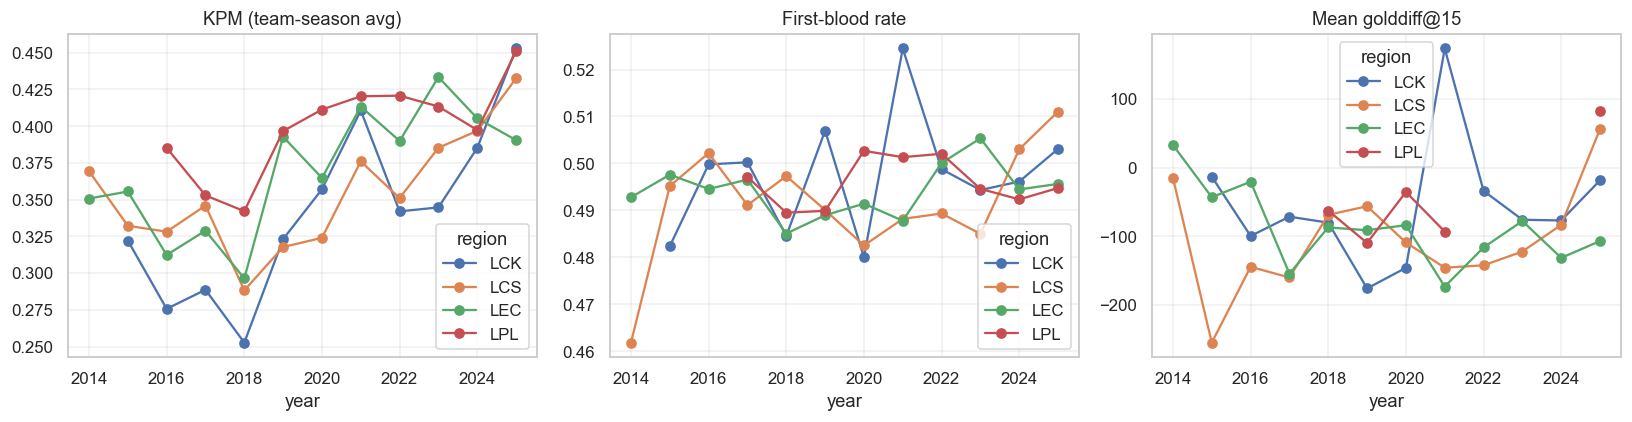

In [19]:
main = ["LPL", "LCK", "LCS", "LEC"]
yearly = (
    filt[filt["region"].isin(main)]
    .groupby(["year", "region"])[["kpm", "fb_rate", "golddiff15_avg"]]
    .mean()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, metric, title in zip(
    axes,
    ["kpm", "fb_rate", "golddiff15_avg"],
    ["KPM (team-season avg)", "First-blood rate", "Mean golddiff@15"],
    strict=False,
):
    yearly[metric].unstack("region").plot(ax=ax, marker="o")
    ax.set_title(title)
    ax.set_xlabel("year")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

我们取一些实际的队伍来验证这个指标是否正确且合理。

> 后面可以放 S12 T1 的侵略性


In [20]:
# 2024 LPL 内部按 KPM 排序，看 top/bottom 是否符合直觉
sample = filt.query("year == 2024 and region == 'LPL'").sort_values("kpm", ascending=False)
print("--- LPL 2024 by KPM ---")
print(sample[["teamname", "games", "kpm", "fb_rate", "golddiff15_avg"]].to_string(index=False))


--- LPL 2024 by KPM ---
           teamname  games      kpm  fb_rate  golddiff15_avg
    Bilibili Gaming    100 0.553175 0.640000             NaN
        Top Esports    104 0.465123 0.461538             NaN
    Anyone's Legend     86 0.443826 0.546512             NaN
    FunPlus Phoenix     86 0.432922 0.534884             NaN
          JD Gaming    103 0.430018 0.456311             NaN
  Ninjas in Pyjamas    111 0.422846 0.612613             NaN
 ThunderTalk Gaming     74 0.399250 0.445946             NaN
       Weibo Gaming    107 0.391028 0.495327             NaN
    Invictus Gaming     84 0.390090 0.547619             NaN
          Oh My God     75 0.388796 0.400000             NaN
        LNG Esports     94 0.385647 0.489362             NaN
          Rare Atom     78 0.376118 0.525641             NaN
         LGD Gaming     82 0.361691 0.390244             NaN
      EDward Gaming     69 0.333138 0.507246             NaN
        Ultra Prime     74 0.332147 0.445946             NaN


### Early-Game Dominance

CSD@10, golddiff@10, xpdiff@10. 衡量队伍在前 10 分钟相对对手建立优势的程度。

> **⚠️ 数据覆盖警告**
>
> 本节所有指标依赖 `*at10` 时间快照字段，受 Oracle's Elixir 上游采集口径限制：
>
> - LPL 在 2014-15 未被收录；2016-17 和 2022-24 全部被标记为 `datacompleteness == 'partial'`，时间快照字段缺失
> - 因此 LPL 在本节图表中会出现长时间空缺，这是数据缺口而非 bug
> - §4.1 Aggression 与 §4.4 Objective focus 不依赖 snapshot，LPL 覆盖完整，可作交叉验证

> **指标本质限制**
>
> `*diffat10` 是带符号的相对优势——同一赛区内强队领先 = 弱队落后，**算术上必然抵消到 0 附近**。因此本节不做"哪个赛区前 10 分钟更强"的赛区均值对比（无意义），而是用以下三种视角：
>
> 1. **赛区内最具早期统治力的队伍**（top teams 排序）
> 2. **赛区内分化程度**（std）——方差大 = 强弱队拉得开
> 3. **国际赛跨区对比**（按"home region"分组的国际赛表现）—— 这才是真正能比较"哪个赛区在国际舞台前期更强"的视角


In [21]:
early_df = early_dominance(df)
print(f"team-season rows with snapshot data: {len(early_df):,}")
early_df.describe()


team-season rows with snapshot data: 5,060


,year,games_snap,csd10_avg,golddiff10_avg,xpdiff10_avg
count,5060.000000,5060.000000,5060.000000,5060.000000,5060.000000
mean,2020.773913,32.607312,-2.937700,-158.845799,-108.013223
std,2.930012,26.834115,13.828902,704.300578,516.774492
min,2014.000000,1.000000,-93.000000,-6200.000000,-4445.500000
25%,2019.000000,9.000000,-10.079244,-457.596292,-344.555556
50%,2021.000000,27.000000,-1.778499,-76.391775,-51.487654
75%,2023.000000,49.000000,5.500000,242.027473,194.071994
max,2025.000000,148.000000,56.000000,2607.333333,1948.071429


In [22]:
# 2024 主赛区里 csd10 最高的队伍
top_early = early_df.query("year == 2024 and region in @main and games_snap >= 20").sort_values(
    "csd10_avg", ascending=False
)
print("=== Most/least early-dominant teams in 2024 ===")
print(
    top_early[["teamname", "region", "games_snap", "csd10_avg", "golddiff10_avg", "xpdiff10_avg"]]
    .head(10)
    .to_string(index=False)
)
print("...")
print(
    top_early[["teamname", "region", "games_snap", "csd10_avg", "golddiff10_avg", "xpdiff10_avg"]]
    .tail(5)
    .to_string(index=False)
)


=== Most/least early-dominant teams in 2024 ===
           teamname region  games_snap  csd10_avg  golddiff10_avg  xpdiff10_avg
             Cloud9    LCS          47  16.234043      632.829787    438.021277
                 T1    LCK         119  14.126050      535.361345    417.025210
              Gen.G    LCK         112  12.839286      434.401786    427.473214
             Fnatic    LEC          85   9.529412      209.694118    398.282353
      Team Vitality    LEC          46   7.826087      248.456522    226.782609
         G2 Esports    LEC          88   6.227273      169.738636    178.965909
           FlyQuest    LCS          64   5.796875      175.625000    349.734375
         KT Rolster    LCK         105   4.066667      208.723810    150.104762
Hanwha Life Esports    LCK         124   3.741935      203.483871     57.943548
          Dplus Kia    LCK         126   2.753968      223.412698     46.373016
...
         teamname region  games_snap  csd10_avg  golddiff10_avg  xpd

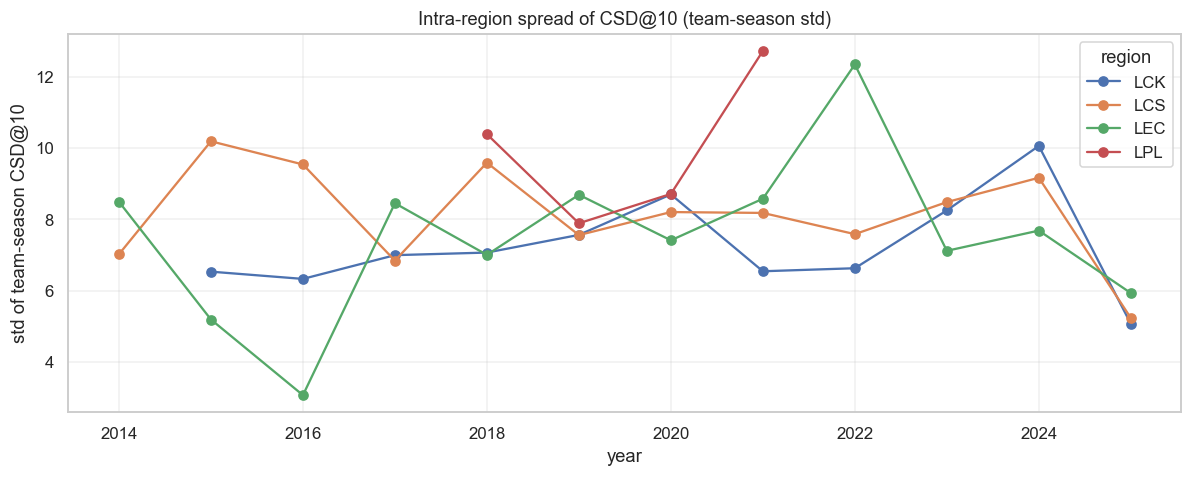

In [23]:
# 视角 2：赛区内"分化程度"——队伍间 csd10_avg 的标准差
# 越大说明该赛区强弱队拉得开；越小说明整体水平接近
main = ["LPL", "LCK", "LCS", "LEC"]
spread = (
    early_df.query("region in @main and games_snap >= 20")
    .groupby(["year", "region"])["csd10_avg"]
    .std()
    .unstack("region")
)

fig, ax = plt.subplots(figsize=(11, 4.5))
spread.plot(ax=ax, marker="o")
ax.set_title("Intra-region spread of CSD@10 (team-season std)")
ax.set_ylabel("std of team-season CSD@10")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ax.legend(title="region")
plt.tight_layout()
plt.show()


In [24]:
# 视角 3：国际赛跨区对比
# 每支队的"home region" = 非国际赛中场次最多的那个 region
# 然后按 home region 平均，看哪个赛区在国际赛上前期最强
home_region = (
    early_df.query("region != 'International' and games_snap >= 10")
    .sort_values("games_snap", ascending=False)
    .drop_duplicates("teamname")
    .set_index("teamname")["region"]
)

intl = early_df[early_df["region"] == "International"].copy()
intl["home_region"] = intl["teamname"].map(home_region)

intl_by_home = (
    intl.query("home_region in @main and games_snap >= 5")
    .groupby("home_region")[["csd10_avg", "golddiff10_avg", "xpdiff10_avg"]]
    .mean()
    .round(2)
)
print("=== Average early-game dominance in International events, by home region ===")
print(intl_by_home)


=== Average early-game dominance in International events, by home region ===
             csd10_avg  golddiff10_avg  xpdiff10_avg
home_region                                         
LCK               3.75          188.71        139.01
LCS              -0.82          -53.19         -8.02
LEC               0.64          -46.63        -29.54
LPL               2.93          176.94         94.16


### Vision Control

Vision score, wards placed/killed.


In [25]:
vis_df = vision_control(df)
print(f"team-season rows: {len(vis_df):,}")
vis_df.describe()

team-season rows: 5,395


,year,games_vision,vs_avg,wards_placed_avg,wards_killed_avg,ctrl_wards_avg
count,5395.000000,5395.000000,5256.000000,5395.000000,5395.000000,5395.000000
mean,2020.751807,34.554402,196.337381,99.469167,41.107316,32.999924
std,2.925052,29.098285,81.493048,20.926593,10.323603,10.262094
min,2014.000000,1.000000,0.000000,25.000000,4.000000,3.000000
25%,2019.000000,10.000000,180.490789,86.000000,34.450806,25.827957
50%,2021.000000,28.000000,218.519231,98.516129,40.972973,33.900000
75%,2023.000000,51.000000,245.891350,112.594693,47.757353,40.500000
max,2025.000000,157.000000,532.000000,281.857143,138.428571,81.500000


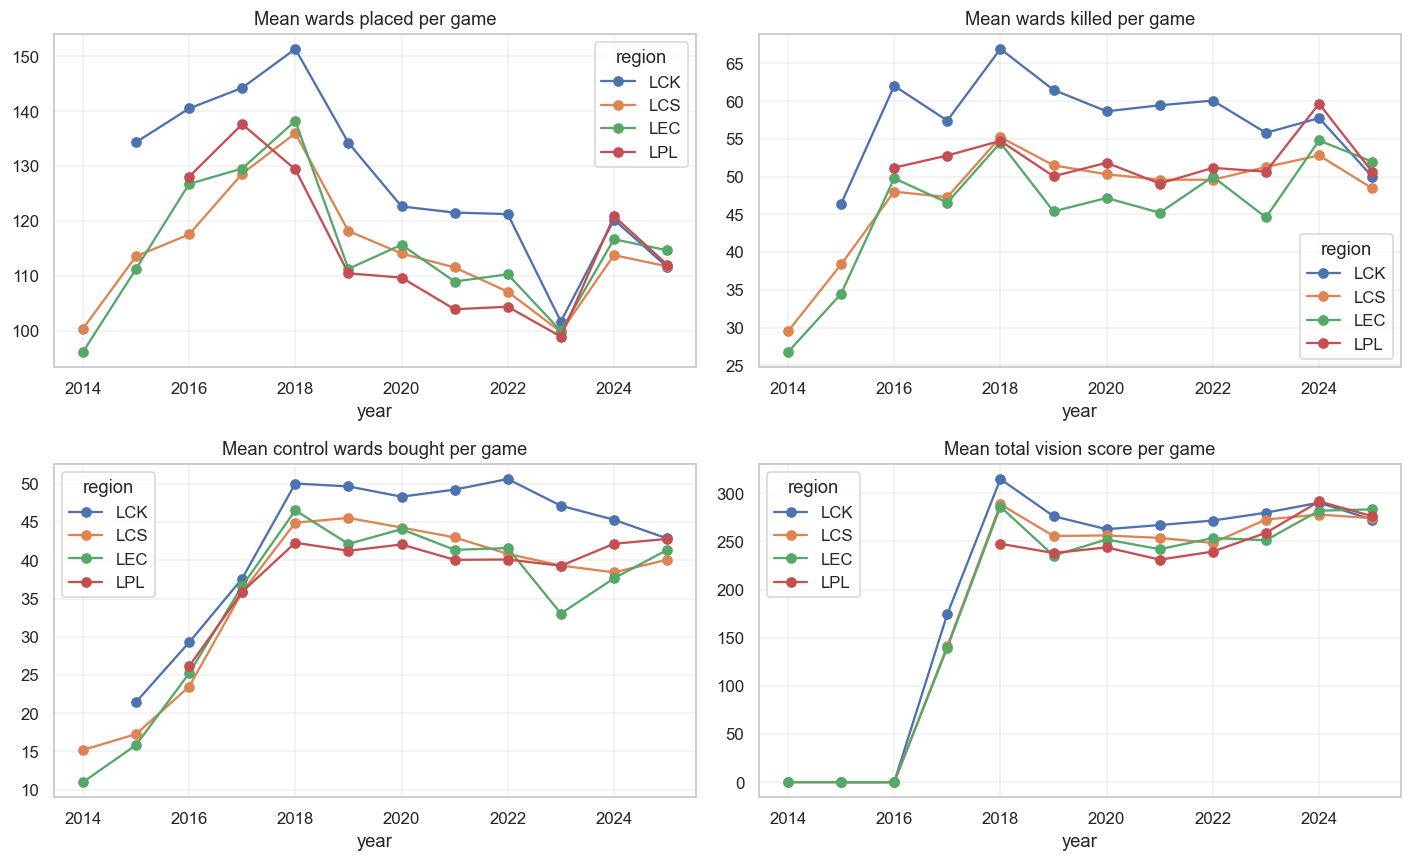

In [26]:
main = ["LPL", "LCK", "LCS", "LEC"]
filt_vis = vis_df.query("region in @main and games_vision >= 10")

yearly = filt_vis.groupby(["year", "region"])[
    ["wards_placed_avg", "wards_killed_avg", "ctrl_wards_avg", "vs_avg"]
].mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
metrics = [
    ("wards_placed_avg", "Mean wards placed per game"),
    ("wards_killed_avg", "Mean wards killed per game"),
    ("ctrl_wards_avg", "Mean control wards bought per game"),
    ("vs_avg", "Mean total vision score per game"),
]
for ax, (metric, title) in zip(axes.flat, metrics):
    yearly[metric].unstack("region").plot(ax=ax, marker="o")
    ax.set_title(title)
    ax.set_xlabel("year")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


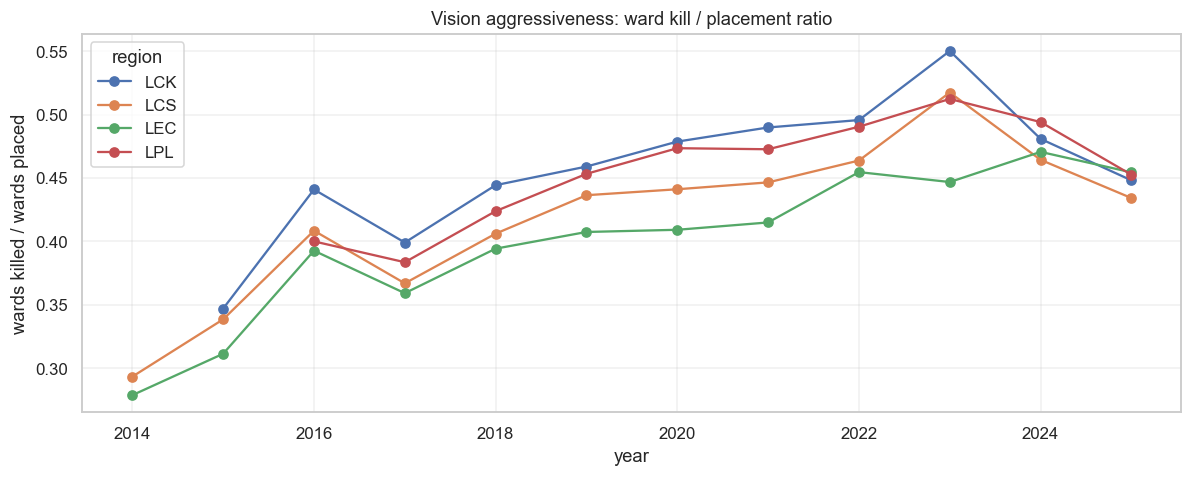

In [27]:
# 反眼率 = wards_killed / wards_placed_opp（但这里直接用比值 wards_killed / wards_placed 作为代理）
# 反眼率：杀眼 / 放眼，越高 = 视野策略越激进（主动反眼 vs 被动放眼）
ward_ratio = (
    filt_vis.assign(kill_place_ratio=lambda d: d["wards_killed_avg"] / d["wards_placed_avg"])
    .groupby(["year", "region"])["kill_place_ratio"]
    .mean()
    .unstack("region")
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ward_ratio.plot(ax=ax, marker="o")
ax.set_title("Vision aggressiveness: ward kill / placement ratio")
ax.set_xlabel("year")
ax.set_ylabel("wards killed / wards placed")
ax.grid(alpha=0.3)
ax.legend(title="region")
plt.tight_layout()
plt.show()


### Objective Focus

地图资源争夺：龙、男爵、峡谷先锋（herald）的拿取倾向。

> **指标本质限制（与 §4.2 同源）**
>
> Count 字段（dragons_avg 等）和 First-X rate 都受**赛区内对称性**影响——同赛区两队对抗，一队拿龙 = 对手不拿，赛区均值必然趋近全局均值的一半（或 0.5）。因此本节同样采用两种视角：
>
> 1. **历年宏观趋势 + patch 节点验证**：展示资源拿取量随版本演化，与 §3.4 patch milestones 对照
> 2. **国际赛跨区对比**：按 home region 分组，看不同赛区在国际舞台上的目标优先级（这才能反映"风格"）

> **数据可用性**
>
> - `dragons` / `barons`（数量）：全年全赛区 100% 覆盖
> - `heralds`（数量）：2016+ 普遍可用（机制 patch 6.22 引入）；LPL 2021 异常掉档
> - `first_dragon` / `first_baron` / `first_herald`（首拿率）：LPL 2016-17 缺，LPL 2022+ `first_baron` / `first_herald` 大部分缺（采集口径）
> - 2014-15 没有 herald 字段；2024-2025 因 Void Grubs / Atakhan 引入，barons / heralds 计数下降是真实机制变化


In [28]:
obj_df = objective_focus(df)
print(f"team-season rows: {len(obj_df):,}")
obj_df.describe()

team-season rows: 5,395


,year,games_obj,dragons_avg,barons_avg,heralds_avg,first_dragon_rate,first_baron_rate,first_herald_rate
count,5395.000000,5395.000000,5395.000000,5395.000000,4851.000000,5140.000000,5079.000000,4821.000000
mean,2020.751807,34.556627,1.857039,0.606363,0.679840,0.486242,0.419298,0.447795
std,2.925052,29.099287,0.747536,0.265776,0.362913,0.168121,0.186958,0.189920
min,2014.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019.000000,10.000000,1.545455,0.459459,0.428571,0.400000,0.320000,0.340000
50%,2021.000000,28.000000,2.000000,0.634615,0.631579,0.500000,0.437500,0.466667
75%,2023.000000,51.000000,2.352397,0.777778,0.969464,0.578947,0.540000,0.571429
max,2025.000000,157.000000,4.333333,2.000000,2.000000,1.000000,1.000000,1.000000


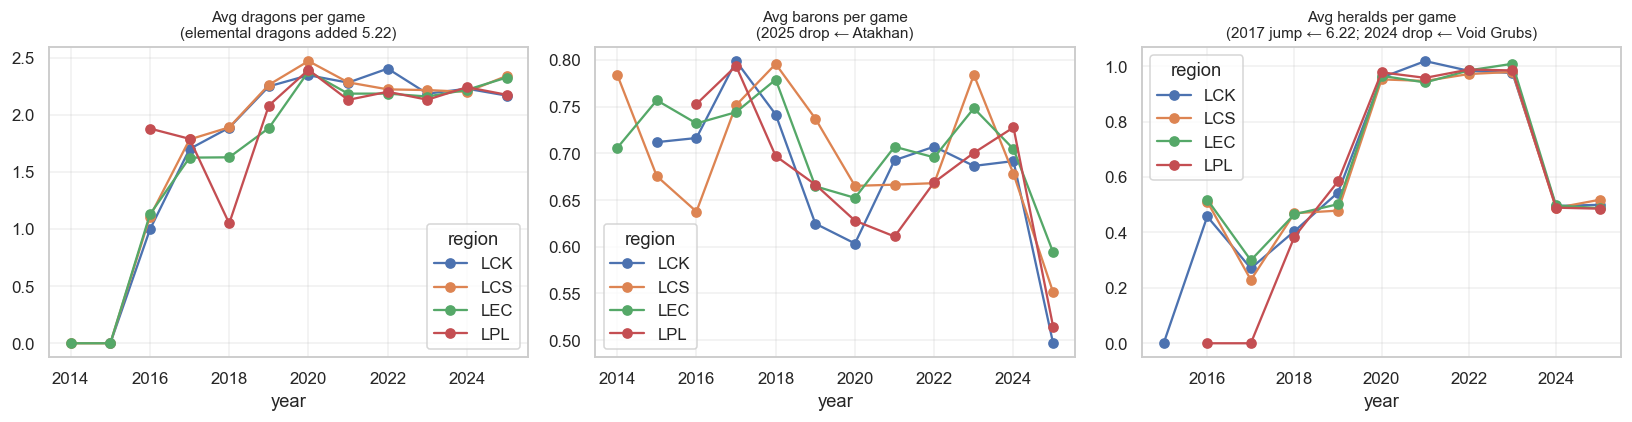

In [29]:
# 视角 1：宏观趋势 + patch 节点验证（不当作赛区差异，因为对称性归零）
main = ["LPL", "LCK", "LCS", "LEC"]
filt_obj = obj_df.query("region in @main and games_obj >= 10")

yearly = filt_obj.groupby(["year", "region"])[["dragons_avg", "barons_avg", "heralds_avg"]].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(
    axes,
    ["dragons_avg", "barons_avg", "heralds_avg"],
    [
        "Avg dragons per game\n(elemental dragons added 5.22)",
        "Avg barons per game\n(2025 drop ← Atakhan)",
        "Avg heralds per game\n(2017 jump ← 6.22; 2024 drop ← Void Grubs)",
    ],
    strict=False,
):
    yearly[metric].unstack("region").plot(ax=ax, marker="o")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("year")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:
# 视角 2：国际赛跨区对比（按 home region）
# 同 §4.2 做法：先识别每支队伍的 home region（非国际赛中场次最多的那个），
# 再看国际赛上不同 home region 的平均目标拿取
home_region_obj = (
    obj_df.query("region != 'International' and games_obj >= 10")
    .sort_values("games_obj", ascending=False)
    .drop_duplicates("teamname")
    .set_index("teamname")["region"]
)

intl_obj = obj_df[obj_df["region"] == "International"].copy()
intl_obj["home_region"] = intl_obj["teamname"].map(home_region_obj)

intl_by_home_obj = (
    intl_obj.query("home_region in @main and games_obj >= 5")
    .groupby("home_region")[
        [
            "dragons_avg",
            "barons_avg",
            "heralds_avg",
            "first_dragon_rate",
            "first_baron_rate",
            "first_herald_rate",
        ]
    ]
    .mean()
    .round(3)
)
print("=== Objective focus in International events, by home region ===")
print(intl_by_home_obj)


=== Objective focus in International events, by home region ===
             dragons_avg  barons_avg  heralds_avg  first_dragon_rate  first_baron_rate  first_herald_rate
home_region                                                                                              
LCK                2.117       0.742        0.708              0.542             0.539              0.481
LCS                1.540       0.615        0.549              0.505             0.431              0.370
LEC                1.489       0.631        0.550              0.412             0.415              0.381
LPL                1.883       0.683        0.698              0.504             0.486              0.465


### Game Length as a Proxy for Macro Style


## 5. Regional Style Comparison


### Head-to-Head Comparison

Major regions: LPL, LCK, LCS, LEC, others.


In [31]:
playstyle = build_playstyle_table(df)
print(f"Total team-season-region rows: {len(playstyle):,}")
playstyle.head()


Total team-season-region rows: 5,395


,teamname,year,region,games,kpm,fb_rate,golddiff15_avg,games_snap,csd10_avg,golddiff10_avg,xpdiff10_avg,games_vision,vs_avg,wards_placed_avg,wards_killed_avg,ctrl_wards_avg,games_obj,dragons_avg,barons_avg,heralds_avg,first_dragon_rate,first_baron_rate,first_herald_rate
0,100 Thieves,2018,International,6,0.408802,0.500000,-1189.833333,6.0,-9.500000,-224.333333,-561.000000,6,212.000000,87.666667,37.833333,37.833333,6,1.000000,0.500000,0.333333,0.333333,0.333333,0.333333
1,100 Thieves,2018,LCS,59,0.290764,0.627119,-7.440678,59.0,-4.016949,30.644068,151.135593,59,304.254237,131.949153,63.745763,44.830508,59,1.915254,0.915254,0.389831,0.508475,0.474576,0.389831
2,100 Thieves,2019,LCS,37,0.246701,0.378378,-878.972973,37.0,-12.054054,-430.486486,-43.729730,37,251.405405,112.891892,51.675676,44.054054,37,1.783784,0.567568,0.432432,0.351351,0.378378,0.432432
3,100 Thieves,2020,LCS,49,0.324374,0.448980,-732.979167,48.0,-2.250000,-199.562500,-66.312500,49,252.061224,109.448980,49.020408,42.979592,49,2.489796,0.551020,0.959184,0.489796,0.326531,0.571429
4,100 Thieves,2021,International,6,0.345821,0.333333,-797.666667,6.0,-9.833333,507.166667,480.500000,6,280.333333,141.000000,51.500000,52.833333,6,2.333333,0.500000,0.666667,0.666667,0.500000,0.166667


In [32]:
WINDOW = list(range(2020, 2025))  # 2020-2024
MAIN = ["LPL", "LCK", "LCS", "LEC"]

# 只用对称性免疫的指标（绝对量 / 比值，不是 diff）
# 注：KPM 这里用 team-level，理论上 region 平均跟全局相同；但 vision 是真有差异的
domestic = (
    playstyle.query("region in @MAIN and year in @WINDOW and games >= 20")
    .assign(kill_place_ratio=lambda d: d["wards_killed_avg"] / d["wards_placed_avg"])
    .groupby("region")[
        ["wards_placed_avg", "wards_killed_avg", "ctrl_wards_avg", "vs_avg", "kill_place_ratio"]
    ]
    .mean()
    .round(2)
    .reindex(MAIN)
)
print("=== Domestic-league fingerprint (2020-2024 averages) ===")
print(domestic)


=== Domestic-league fingerprint (2020-2024 averages) ===
        wards_placed_avg  wards_killed_avg  ctrl_wards_avg  vs_avg  kill_place_ratio
region                                                                              
LPL               107.65             52.59           40.86  252.88              0.49
LCK               118.68             58.92           48.57  275.79              0.50
LCS               108.89             50.64           41.24  261.41              0.47
LEC               110.32             48.35           39.54  256.18              0.44


In [33]:
# 单场 KPM、gamelength —— 这两个是单场属性，不受 team symmetry 影响
macro = (
    games_kpm.query("region in @MAIN and year in @WINDOW")
    .groupby("region")
    .agg(
        median_kpm=("kpm", "median"),
        median_gamelength_min=("gamelength_min", "median"),
        games_total=("gameid", "size"),
    )
    .reindex(MAIN)
    .round(2)
)
print("=== Macro-level fingerprint (per-game metrics, 2020-2024) ===")
print(macro)


=== Macro-level fingerprint (per-game metrics, 2020-2024) ===
        median_kpm  median_gamelength_min  games_total
region                                                
LPL           0.82                  31.03         3994
LCK           0.71                  31.98         2538
LCS           0.74                  32.17         1371
LEC           0.82                  31.80         1313


In [34]:
# 算每队的 home region
home_region_map = (
    playstyle.query("region != 'International' and games >= 10")
    .sort_values("games", ascending=False)
    .drop_duplicates("teamname")
    .set_index("teamname")["region"]
)

intl_full = playstyle[
    (playstyle["region"] == "International") & (playstyle["year"].isin(WINDOW))
].copy()
intl_full["home_region"] = intl_full["teamname"].map(home_region_map)

intl_fp = (
    intl_full.query("home_region in @MAIN and games >= 5")
    .groupby("home_region")[
        [
            "kpm",
            "fb_rate",
            "golddiff15_avg",
            "csd10_avg",
            "golddiff10_avg",
            "wards_placed_avg",
            "wards_killed_avg",
            "dragons_avg",
            "barons_avg",
            "first_dragon_rate",
            "first_baron_rate",
        ]
    ]
    .mean()
    .reindex(MAIN)
    .round(3)
)
print("=== International cross-region fingerprint (2020-2024) ===")
print(intl_fp)


=== International cross-region fingerprint (2020-2024) ===
               kpm  fb_rate  golddiff15_avg  csd10_avg  golddiff10_avg  wards_placed_avg  wards_killed_avg  dragons_avg  barons_avg  first_dragon_rate  \
home_region                                                                                                                                              
LPL          0.424    0.534         506.316      2.623         187.054           111.733            55.376        2.296       0.686              0.518   
LCK          0.404    0.530         668.162      4.871         266.458           120.643            56.229        2.369       0.759              0.493   
LCS          0.376    0.405        -420.983     -2.155        -103.426           107.285            48.159        1.971       0.634              0.506   
LEC          0.415    0.515        -596.032     -2.522        -166.145           107.066            49.019        1.943       0.567              0.378   

             fir

In [35]:
# 看每个指标的 region 之间最大-最小差距，找出"最具区分度"的指标
def region_spread(df_summary):
    return (df_summary.max() - df_summary.min()).sort_values(ascending=False)


print("=== Most region-distinguishing metrics (Domestic) ===")
print(region_spread(domestic).head(8))

print("\n=== Most region-distinguishing metrics (International) ===")
print(region_spread(intl_fp).head(8))


=== Most region-distinguishing metrics (Domestic) ===
vs_avg              22.91
wards_placed_avg    11.03
wards_killed_avg    10.57
ctrl_wards_avg       9.03
kill_place_ratio     0.06
dtype: float64

=== Most region-distinguishing metrics (International) ===
golddiff15_avg      1264.194
golddiff10_avg       432.603
wards_placed_avg      13.577
wards_killed_avg       8.070
csd10_avg              7.393
dragons_avg            0.426
barons_avg             0.192
first_baron_rate       0.155
dtype: float64


### Per-Metric Breakdown with Visualizations


### Statistical Testing

ANOVA / Kruskal-Wallis to confirm differences are significant.


### Summary: Regional "Fingerprints"


## 6. Patch as a Shaping Force


### Patch Changes vs. Match Tempo


### Did Patches Narrow or Widen Regional Style Gaps?


### Case Study

One or two specific patches with notable meta impact.


## 7. Conclusion


### Key Findings


### Limitations

Data gaps, roster changes, international tournaments not separated.


### Possible Extensions
